In [66]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [67]:
df=pd.read_csv('health_risk_data.csv')
df

,age,bmi,waist_circumference,systolic_bp,diastolic_bp,mean_arterial_pressure,fasting_glucose,hba1c,glucose_monitor_avg,total_cholesterol,ldl_cholesterol,hdl_cholesterol,resting_hr,activity_hr,device_artifact_signal,measurement_variability_index,risk_label
0,49.967142,30.753135,106.721491,109.173937,81.851755,89.232162,110.140405,7.747751,111.790974,204.189550,142.602432,57.177317,48.024990,67.708474,0.906834,1.174814,1
1,43.617357,24.935821,94.149756,122.652313,84.254449,96.991330,98.852093,7.434487,94.782039,201.950739,136.329015,54.816690,82.687139,102.294197,-1.451835,-1.878981,0
2,51.476885,27.384483,92.615870,111.799799,82.222899,92.117899,72.091030,6.598568,70.262644,224.398412,155.355139,69.802697,71.902232,97.894075,-0.664701,-0.327795,0
3,60.230299,25.150899,84.032186,115.925173,92.788658,101.446091,85.841781,7.366348,88.363135,174.684384,129.426386,55.580815,66.203755,86.275437,-0.121075,-0.041660,0
4,42.658466,25.262015,86.003335,145.101781,70.476836,92.618101,94.745065,7.467980,97.352312,147.689822,116.161442,46.307795,78.571584,96.463672,1.365560,0.015909,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,55.531529,22.961077,73.115544,91.799849,80.284576,81.594988,65.144561,6.697116,66.633941,266.295670,168.250479,77.631474,61.406008,85.654232,-1.181194,0.024480,0
796,44.604448,29.476617,98.558861,130.690680,59.221882,84.017184,108.188771,7.780712,110.439549,209.809835,141.725997,58.078811,65.297443,75.733186,-0.072822,-0.962669,1
797,51.815007,35.229982,118.285150,91.752747,76.797022,77.883520,94.466565,6.948320,93.944772,174.946265,131.438943,52.296062,84.985464,113.871937,0.838014,-0.633640,0
798,45.283184,27.083175,95.827449,114.415214,96.433782,98.326878,102.267888,7.832056,111.145342,249.587391,187.273148,77.725012,67.282700,89.701905,-0.100696,-2.256725,1


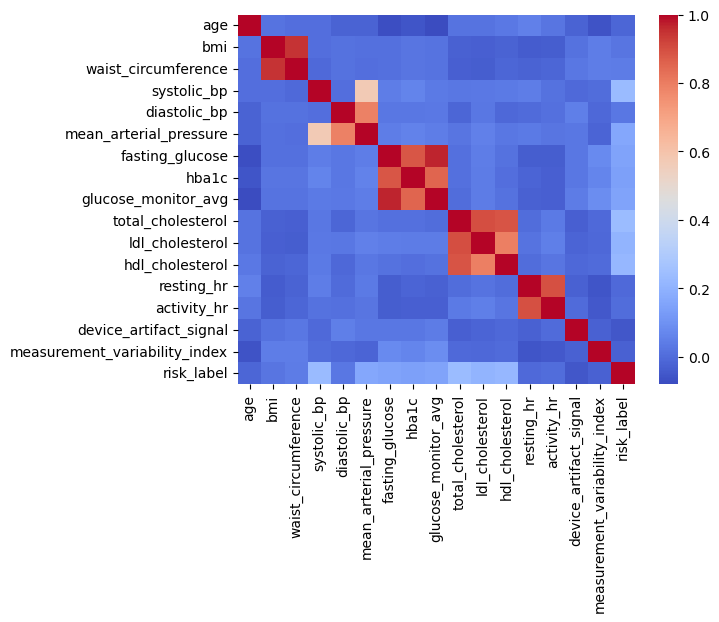

In [68]:
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

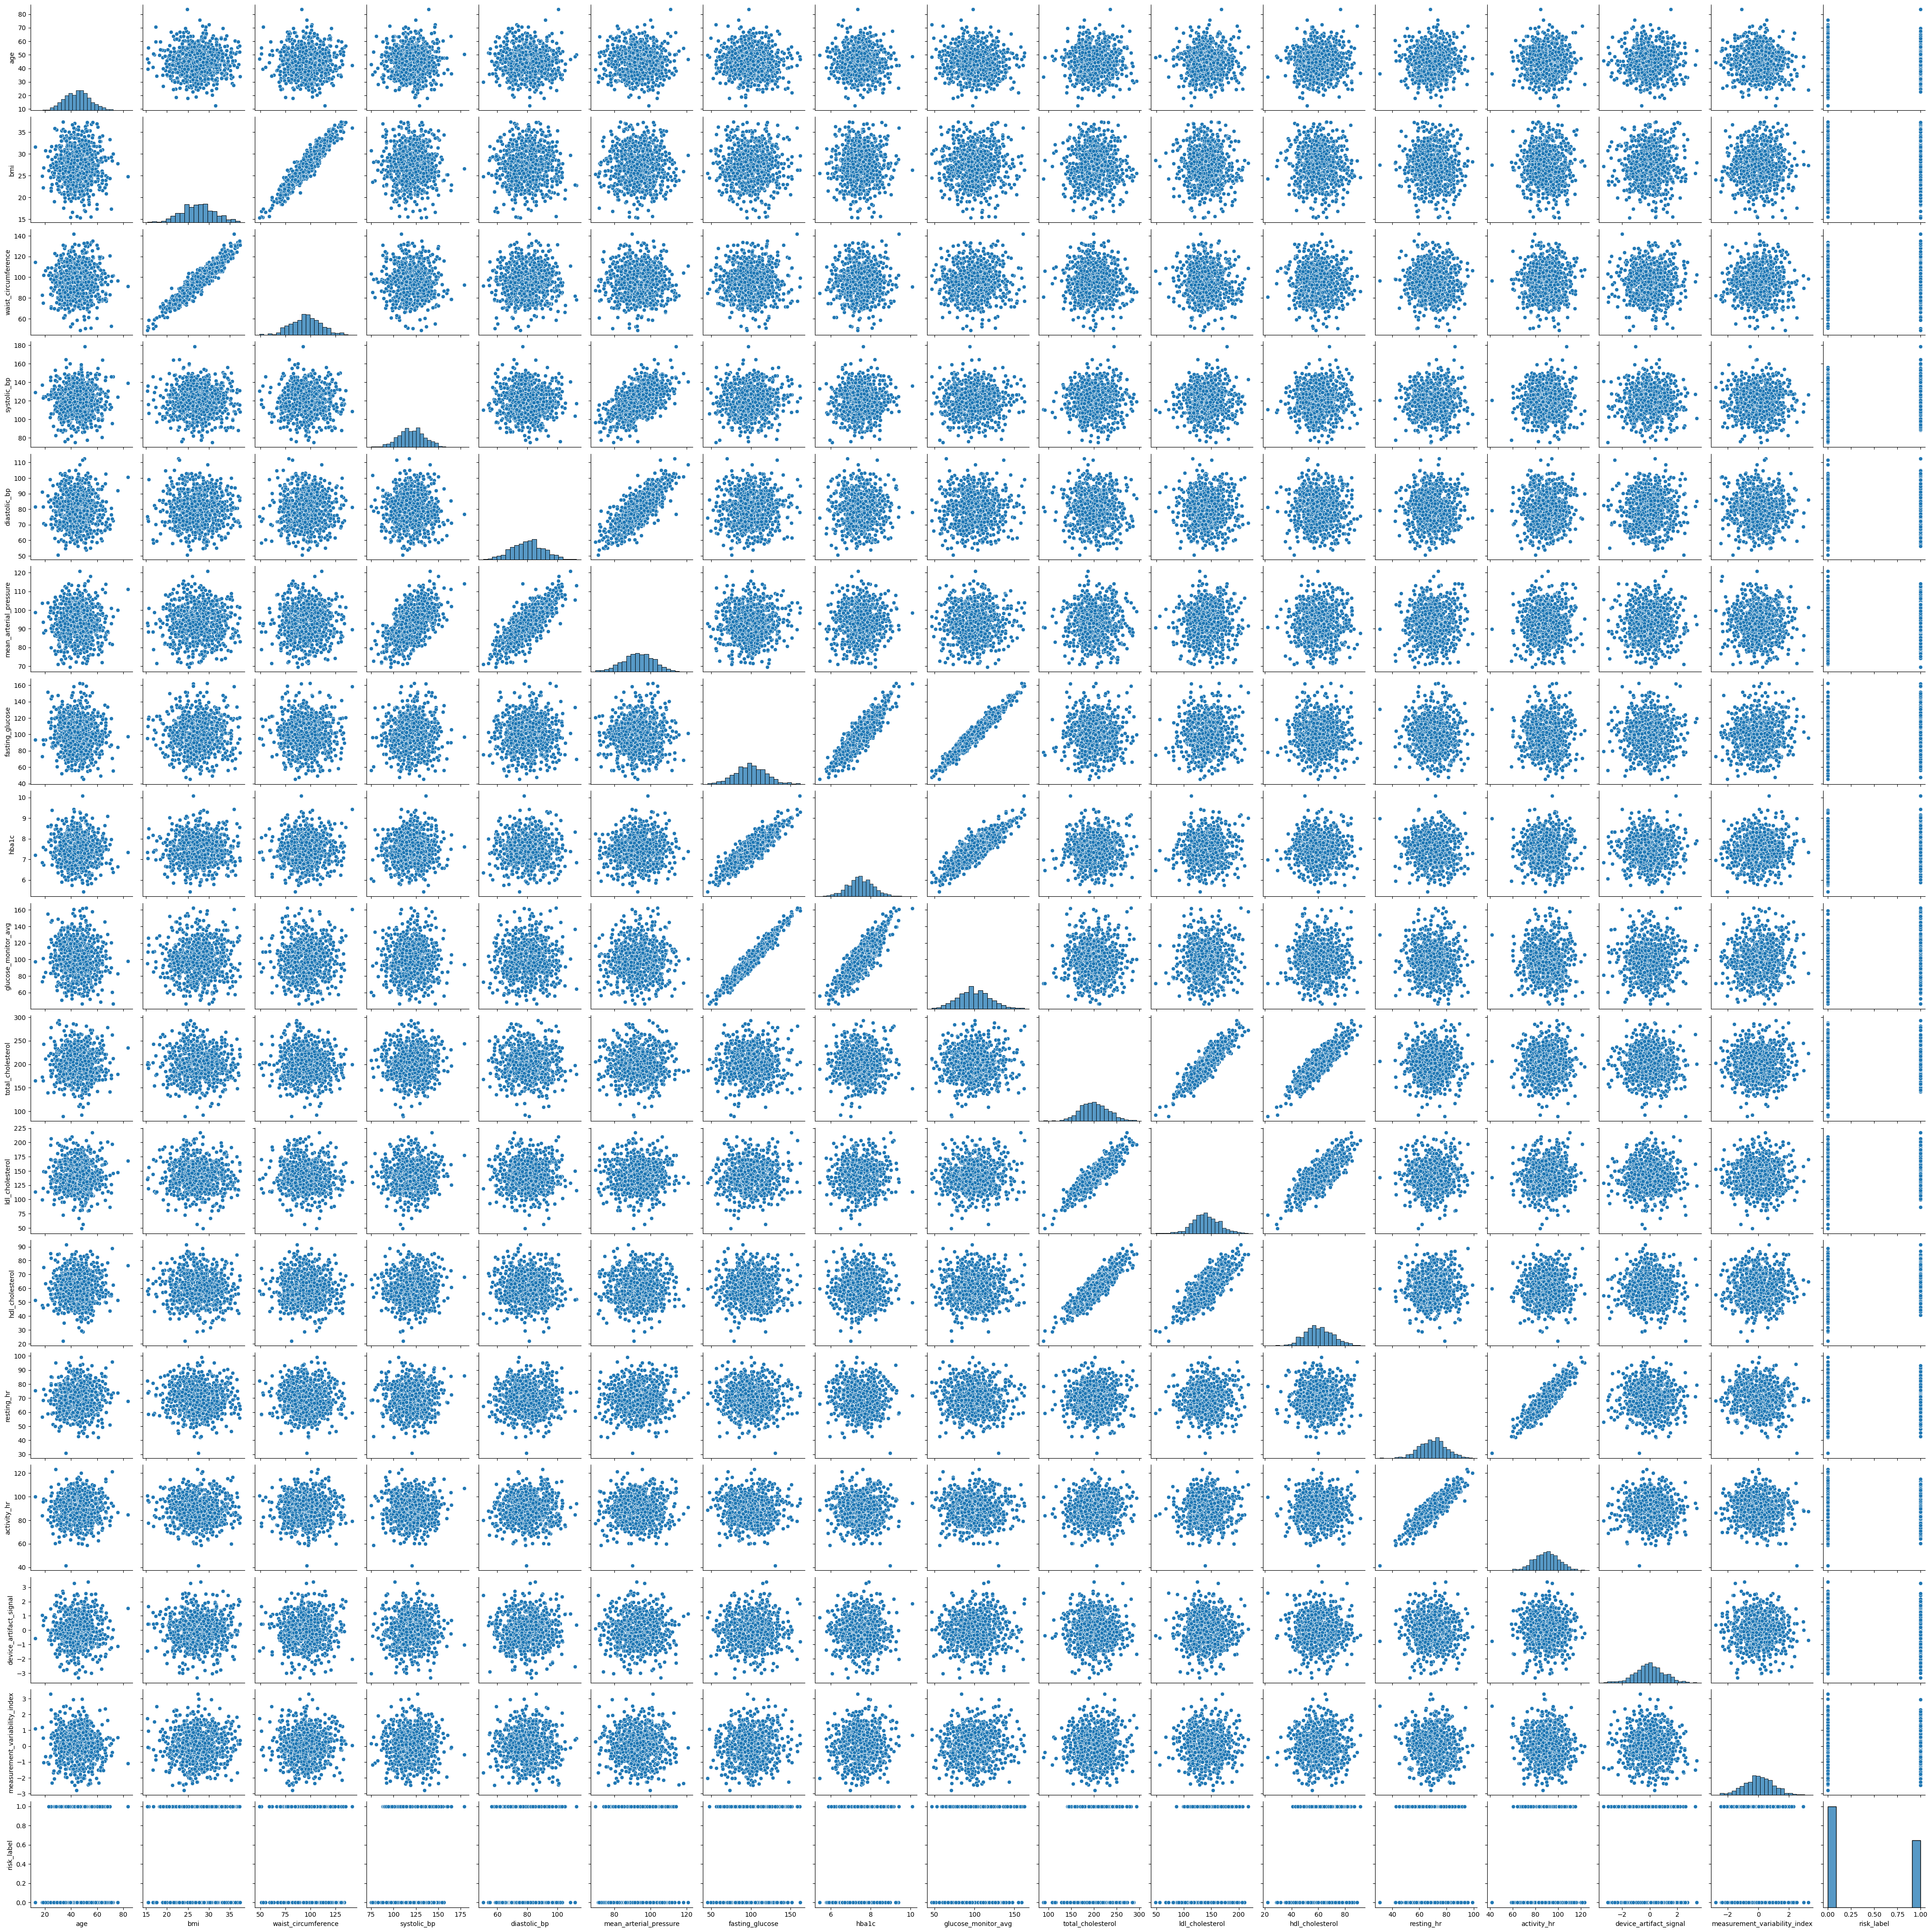

In [69]:
sns.pairplot(df)
plt.show()

In [70]:
dupes=df.duplicated().sum()
dupes

np.int64(0)

In [71]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [86]:
X = df.drop(columns=["risk_label"])
y = df["risk_label"]

In [87]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [88]:
rf = RandomForestClassifier(n_estimators=200,random_state=43,class_weight="balanced")
rf.fit(X1_train, y1_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Accuracy: 0.65625

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.77      0.73        96
           1       0.58      0.48      0.53        64

    accuracy                           0.66       160
   macro avg       0.64      0.63      0.63       160
weighted avg       0.65      0.66      0.65       160



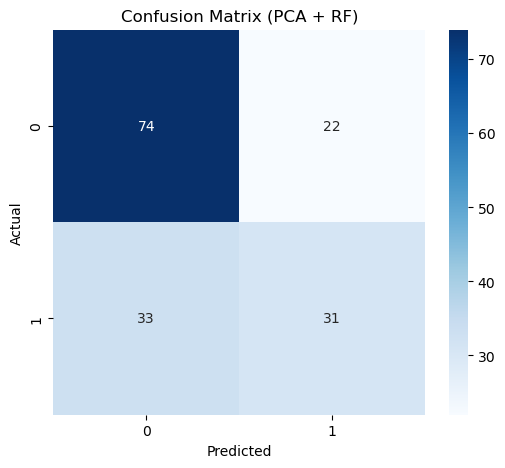

In [89]:
y1_pred = rf.predict(X1_test)
print("Accuracy:", accuracy_score(y1_test, y1_pred))
print("\nClassification Report:\n", classification_report(y1_test, y1_pred))
cm = confusion_matrix(y1_test, y1_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (PCA + RF)")
plt.show()

In [90]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

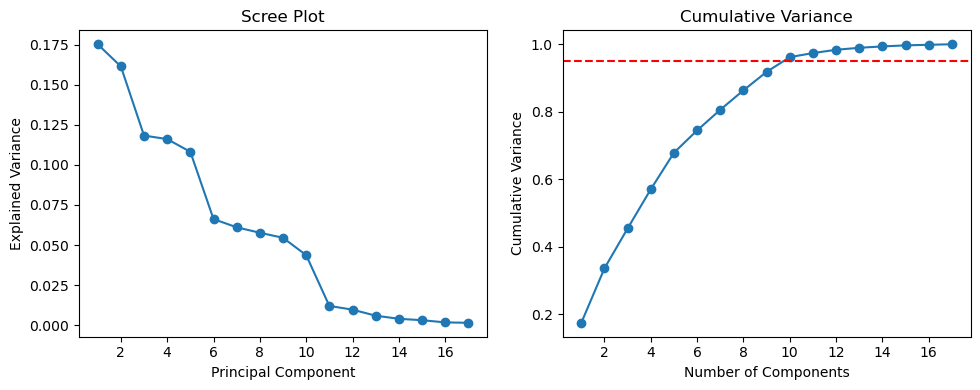

In [91]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(range(1, len(explained_variance)+1),explained_variance,marker='o')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')
plt.subplot(1,2,2)
plt.plot(range(1, len(cumulative_variance)+1),cumulative_variance,marker='o')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.title('Cumulative Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.tight_layout()
plt.show()

In [92]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42, stratify=y)

In [93]:
rf = RandomForestClassifier(n_estimators=200,random_state=43,class_weight="balanced")
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        96
           1       1.00      1.00      1.00        64

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160



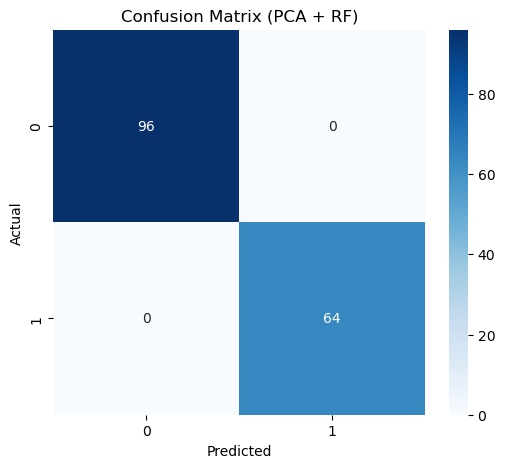

In [94]:
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (PCA + RF)")
plt.show()